# Usage of functions

In this tutorial we compile examples on how to use the differnt functions available in the package. You can refer to previous tutorial to see how to use CellBender and perform quality control and basic downstream analysis of sc/snRNA-seq. We are going to use the object generated in the `Quality control of sc/snRNA-seq`.

In [1]:
# Set-up
import scanpy as sc
import  dotools_py as do

adata = sc.read_h5ad('/tmp/dootools_datasets/adata.h5ad')
adata

2025-06-14 13:27:19,289 - Jupyter enviroment detected. Using "inline" backend


AnnData object with n_obs × n_vars = 2801 × 18517
    obs: 'batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'n_counts', 'doublet_class', 'doublet_score', 'leiden', 'cell_type', 'autoAnnot', 'celltypist_conf_score', 'annotation', 'annotation_recluster'
    var: 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'annotation_colors', 'annotation_recluster_colors', 'autoAnnot_colors', 'batch_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_CCA', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts', 'scaled'
    obsp: 'connectivities', 'distances'

## Dotplot

The dotplot function builds on scanpy Dotplot method, but we also allow for the visualisation of 3 variables at the same time. For example, we can visualise the expression of a gene across celltypes and conditions

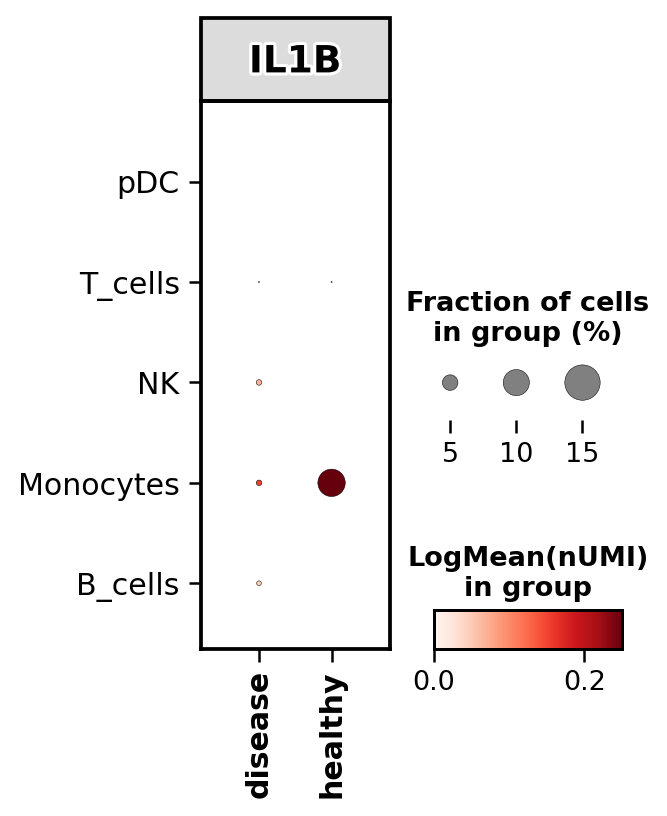

In [4]:
do.pl.dotplot(adata,
              x_axis='condition',
              features='IL1B',
              y_axis='annotation',
              figsize=(3, 4))

## UMAP
With `do.pl.umap()` we can visualise in UMAP embeddings the expression of genes as well as metadata information

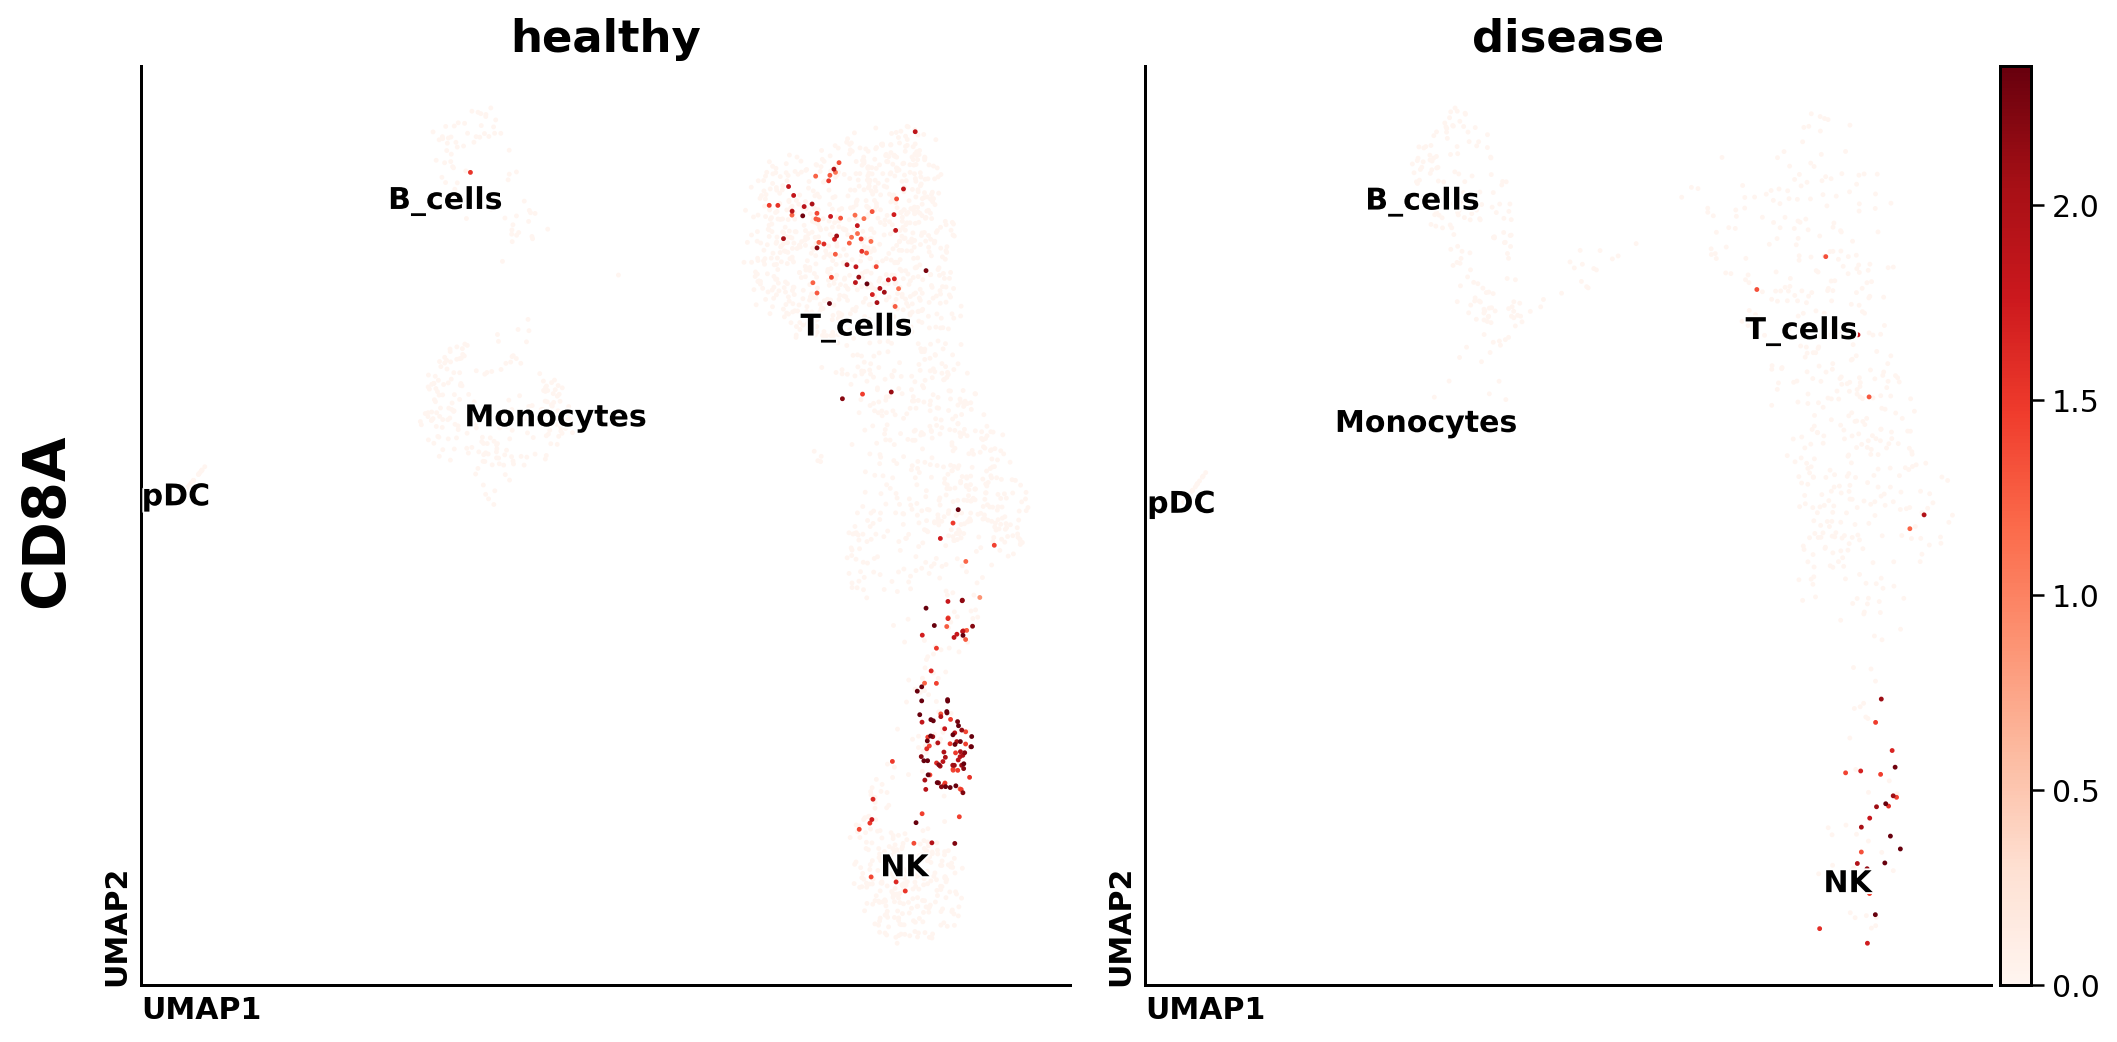

In [11]:
do.pl.umap(adata, 'CD8A', split_by='condition', common_legend=True, size=15,
           labels='annotation')

## Split embeddings

If we have categorical metadata we can visualise it also highlighting the different categories in each subplot

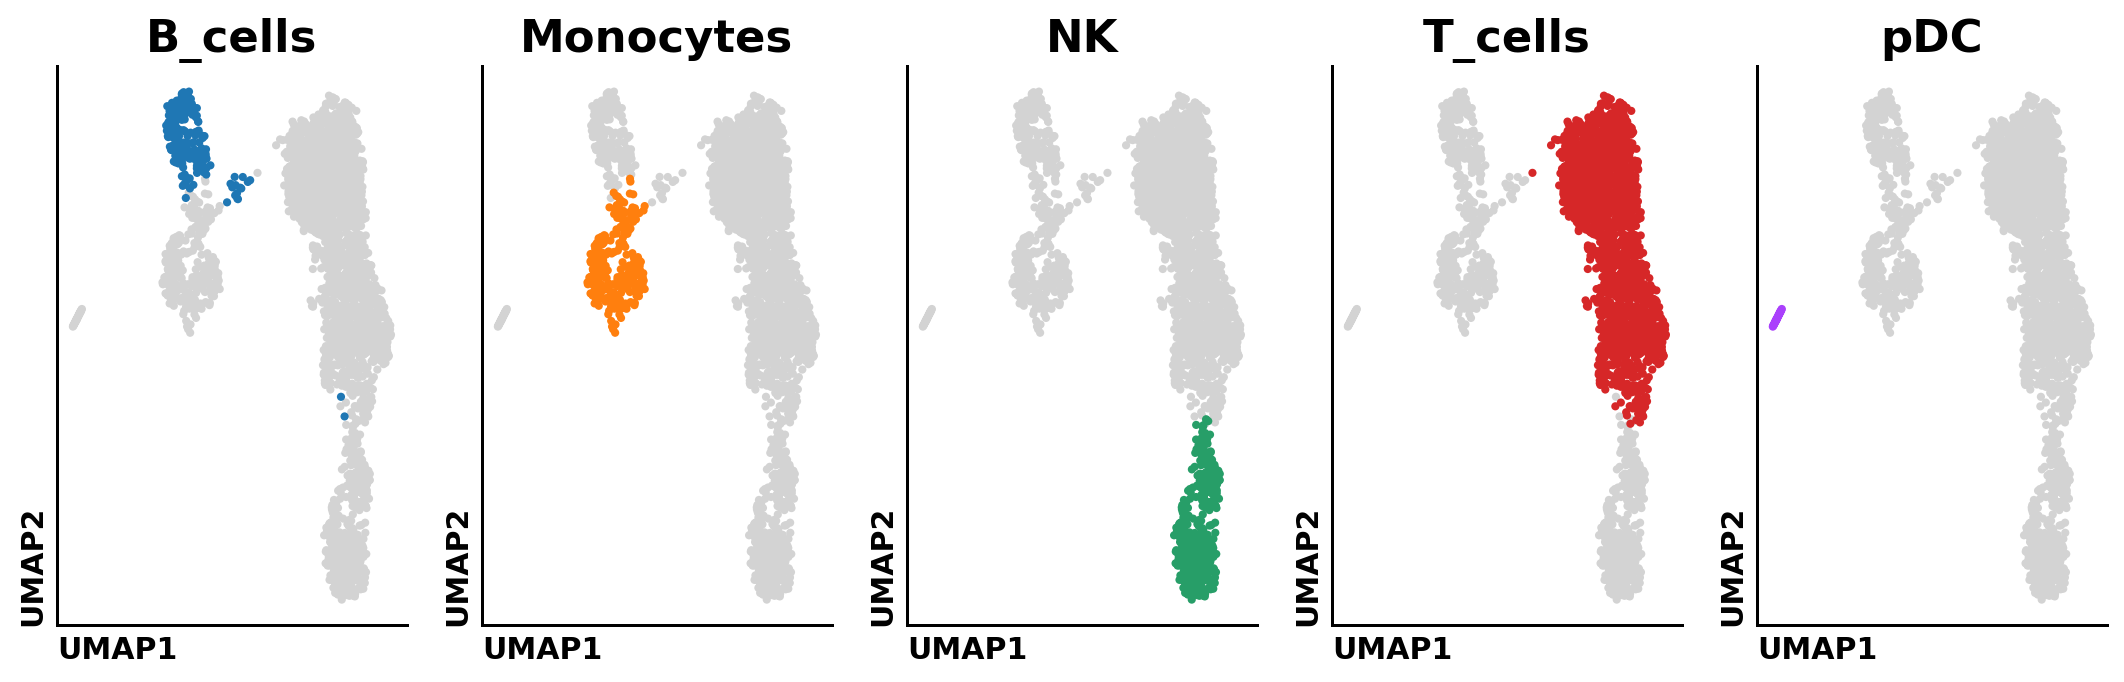

In [16]:
do.pl.split_embeddding(adata, split_by='annotation', ncols=5, figsize=(12, 4))

## Changes in cell proportion

As shown in the tutorial, we can also test for significant changes in cell population.

[INFO] Your data doesn't have replicates! Artificial replicates will be simulated to run scanpro.
[WARNING] Consider setting transform='arcsin', as this produces more accurate results for simulated data.
[INFO] Simulation may take some minutes...
[INFO] Generating 3 replicates and running 100 simulations...
[INFO] Finished 100 simulations in 4.2 seconds
2025-06-14 13:03:46,117 - There are 1 populations with a significant change


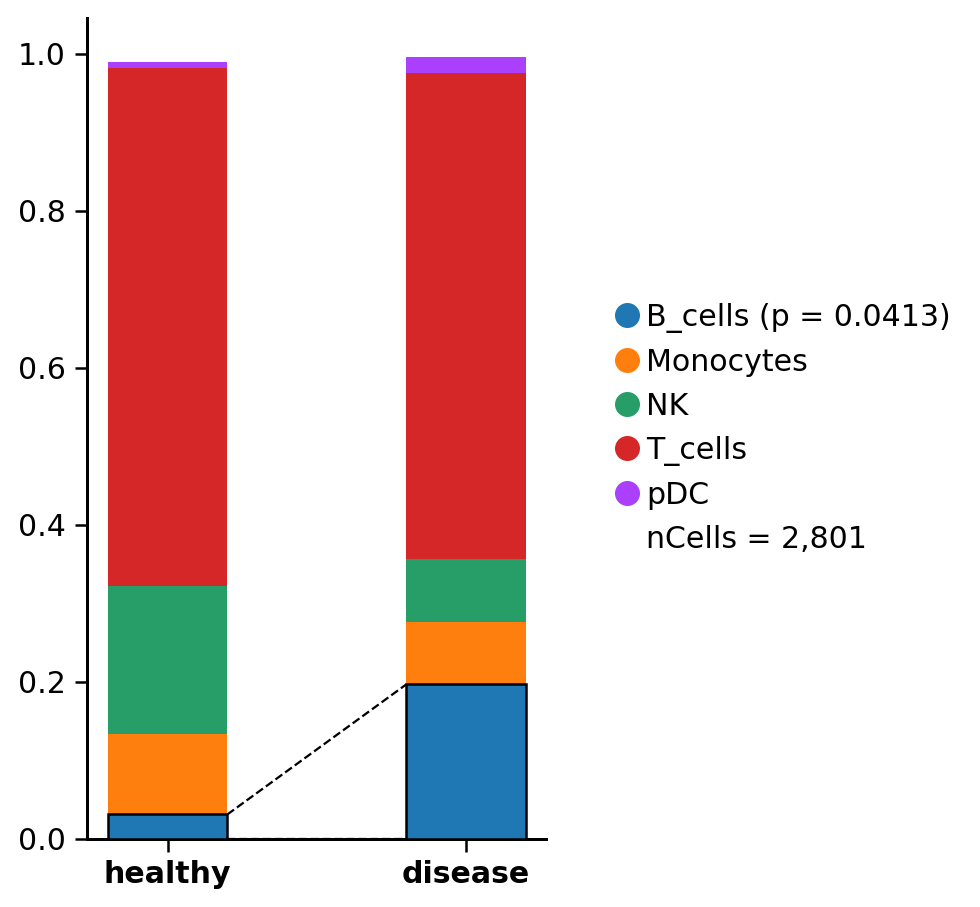

In [18]:
do.pl.cell_props(adata, 'annotation', 'condition', 'batch', cond_order=['healthy', 'disease'])

## Expression of genes and continuous metadata

We can visualise the average expression of a gene in a celltype or continuous metadata information across condition with barplots, violinplots and boxplots. Additionally, we can test for significance.

ranking genes
    finished (0:00:00)


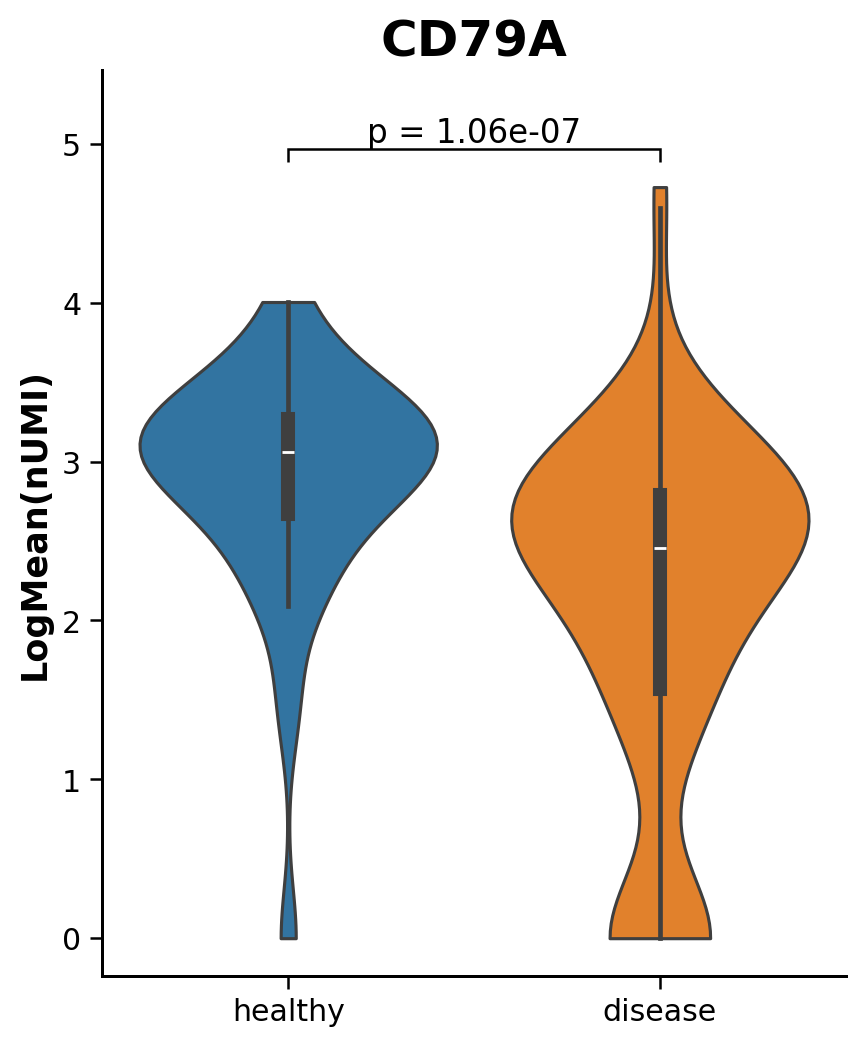

In [3]:
bcell = adata[adata.obs.annotation == 'B_cells']

do.pl.violin(bcell, feature='CD79A', x_axis='condition', ctrl_cond='healthy',
              groups_cond='disease', figsize=(5, 6))

ranking genes
    finished (0:00:00)


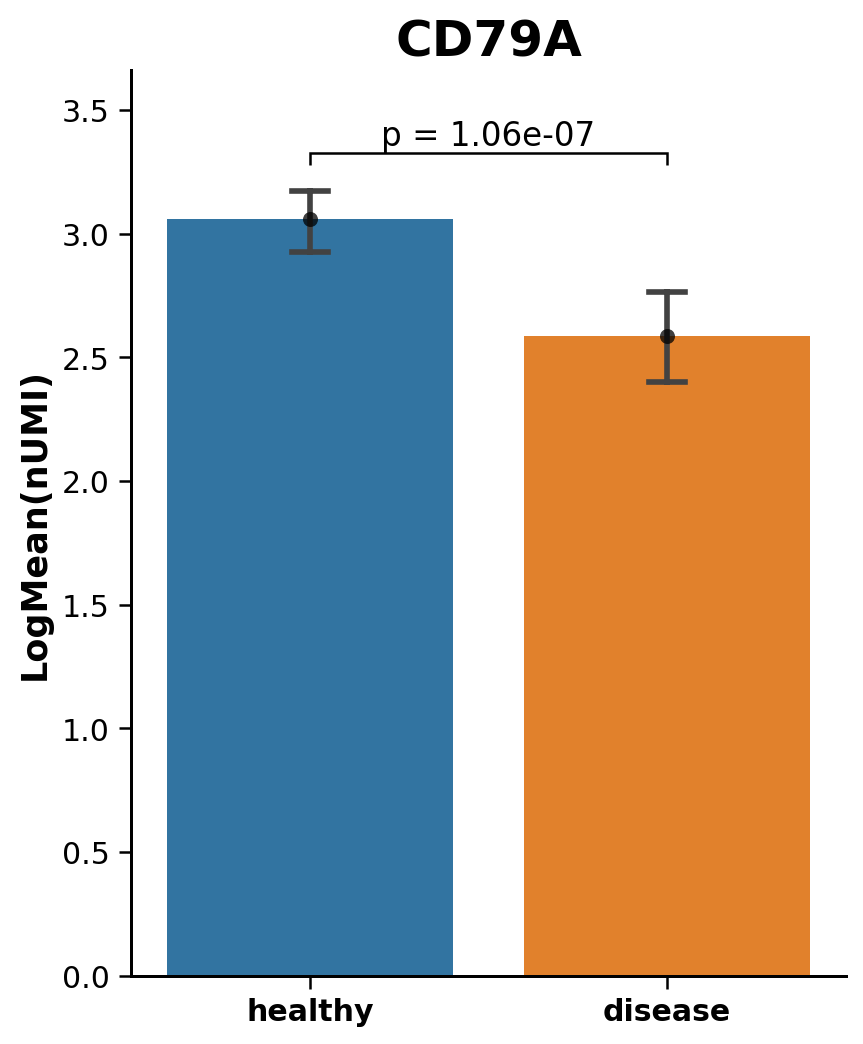

In [4]:
do.pl.barplot(bcell, feature='CD79A', x_axis='condition', ctrl_cond='healthy',
              groups_cond='disease', figsize=(5, 6))

ranking genes
    finished (0:00:00)


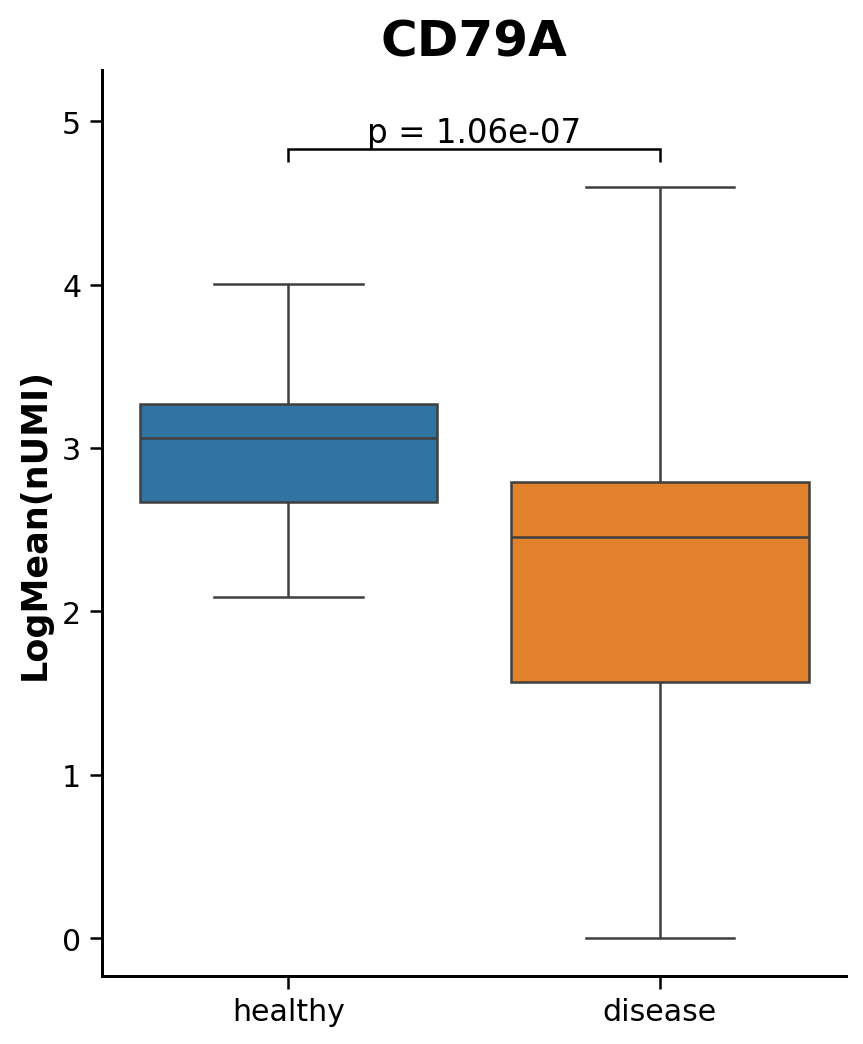

In [5]:
do.pl.boxplot(bcell, feature='CD79A', x_axis='condition', ctrl_cond='healthy',
              groups_cond='disease', figsize=(5, 6))

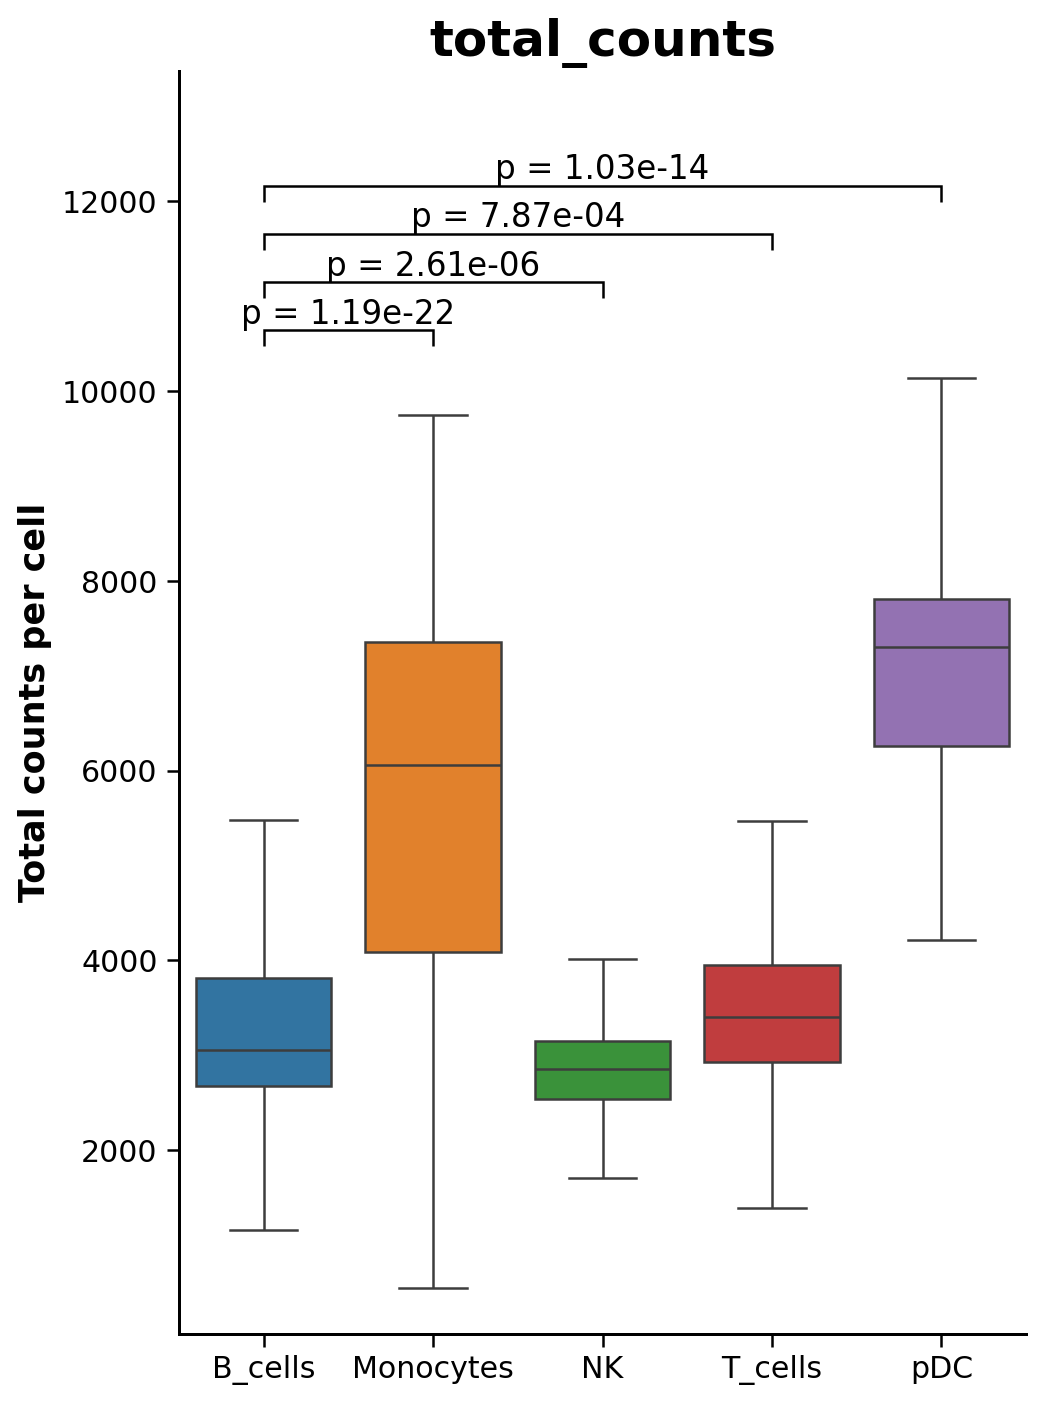

In [11]:
do.pl.boxplot(adata, 'total_counts', 'annotation', ctrl_cond='B_cells', groups_cond=['Monocytes', 'NK', 'T_cells', 'pDC'],
              figsize=(6, 8), ylabel='Total counts per cell')